In [1]:
import numpy as np

def generate_adding_problem(num_samples, seq_len):
    x_values = np.random.uniform(0, 1, (num_samples, seq_len))
    x_mask = np.zeros((num_samples, seq_len))
    
    for i in range(num_samples):
        indices = np.random.choice(seq_len, size=2, replace=False)
        x_mask[i, indices] = 1.0

    X = np.stack([x_values, x_mask], axis=-1)
    y = np.sum(x_values * x_mask, axis=1, keepdims=True)

    return X.astype(np.float32), y.astype(np.float32)

In [2]:
import torch
import random

def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.cuda.manual_seed_all(seed)

In [3]:
import torch
from torch.utils.data import Dataset

class AddingDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [4]:
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

def create_dataloaders(seq_len, batch_size=64):
    X, y = generate_adding_problem(10000, seq_len)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    train_dataset = AddingDataset(X_train, y_train)
    test_dataset = AddingDataset(X_test, y_test)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)

    return train_loader, test_loader

In [5]:
train_loader, test_loader = create_dataloaders(seq_len=50)

for X_batch, y_batch in train_loader:
    print(X_batch.shape)  
    print(y_batch.shape) 
    break

torch.Size([64, 50, 2])
torch.Size([64, 1])


Vanilla RNN

In [6]:
import torch
import torch.nn as nn

class RNNModel(nn.Module):
    def __init__(self, input_size=2, hidden_size=64):
        super().__init__()
        
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True
        )
        
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        last_hidden = out[:, -1, :]
        output = self.fc(last_hidden)
        return output

LSTM

In [7]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=2, hidden_size=64):
        super().__init__()
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True
        )
        
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        last_hidden = out[:, -1, :]
        output = self.fc(last_hidden)
        return output

GRU

In [8]:
class GRUModel(nn.Module):
    def __init__(self, input_size=2, hidden_size=64):
        super().__init__()
        
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True
        )
        
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        last_hidden = out[:, -1, :]
        output = self.fc(last_hidden)
        return output

In [9]:
model = RNNModel()
X_sample = torch.randn(64, 50, 2)
y_pred = model(X_sample)
print(y_pred.shape)

torch.Size([64, 1])


In [10]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [11]:
def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            outputs = model(X)
            loss = criterion(outputs, y)
            total_loss += loss.item() * X.size(0)

    return total_loss / len(dataloader.dataset)

In [ ]:
import time
import numpy as np

def train_model(model, train_loader, test_loader, epochs=50, lr=0.001, device="cpu"):
    
    model.to(device)
    criterion = torch.nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    grad_norms = []
    epoch_times = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        
        start_time = time.time()
        
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            
            optimizer.zero_grad()
            outputs = model(X)
            loss = criterion(outputs, y)
            loss.backward()
            
            total_norm = 0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2
            total_norm = total_norm ** 0.5
            grad_norms.append(total_norm)
            
            optimizer.step()
            
            epoch_loss += loss.item() * X.size(0)
        
        epoch_time = time.time() - start_time
        epoch_times.append(epoch_time)

        epoch_loss /= len(train_loader.dataset)
        train_losses.append(epoch_loss)

        print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.6f} | Time: {epoch_time:.2f}s")

    test_mse = evaluate(model, test_loader, criterion, device)

    return {
        "train_losses": train_losses,
        "grad_norms": grad_norms,
        "epoch_times": epoch_times,
        "test_mse": test_mse
    }

In [13]:
device = "cuda" if torch.cuda.is_available() else "cpu"

train_loader, test_loader = create_dataloaders(seq_len=50)

model = RNNModel()

results = train_model(model, train_loader, test_loader, device=device)

print("Test MSE:", results["test_mse"])
print("Avg time per epoch:", np.mean(results["epoch_times"]))
print("Parameters:", count_parameters(model))

Epoch 1/50 | Loss: 0.186050 | Time: 1.18s
Epoch 2/50 | Loss: 0.166208 | Time: 1.20s
Epoch 3/50 | Loss: 0.167345 | Time: 1.17s
Epoch 4/50 | Loss: 0.166369 | Time: 1.23s
Epoch 5/50 | Loss: 0.165813 | Time: 1.48s
Epoch 6/50 | Loss: 0.165744 | Time: 1.79s
Epoch 7/50 | Loss: 0.166348 | Time: 1.13s
Epoch 8/50 | Loss: 0.166130 | Time: 1.17s
Epoch 9/50 | Loss: 0.166862 | Time: 1.04s
Epoch 10/50 | Loss: 0.165475 | Time: 1.02s
Epoch 11/50 | Loss: 0.166103 | Time: 1.05s
Epoch 12/50 | Loss: 0.165078 | Time: 0.96s
Epoch 13/50 | Loss: 0.165280 | Time: 1.10s
Epoch 14/50 | Loss: 0.164753 | Time: 1.40s
Epoch 15/50 | Loss: 0.166119 | Time: 1.28s
Epoch 16/50 | Loss: 0.165513 | Time: 1.33s
Epoch 17/50 | Loss: 0.164796 | Time: 1.15s
Epoch 18/50 | Loss: 0.164226 | Time: 1.11s
Epoch 19/50 | Loss: 0.166664 | Time: 1.17s
Epoch 20/50 | Loss: 0.166320 | Time: 1.44s
Epoch 21/50 | Loss: 0.165499 | Time: 1.24s
Epoch 22/50 | Loss: 0.164337 | Time: 1.33s
Epoch 23/50 | Loss: 0.165112 | Time: 1.19s
Epoch 24/50 | Loss: 

In [14]:
sequence_lengths = [10, 25, 50, 100, 200, 500]
seeds = [1, 2, 3]

In [17]:
def run_experiment(ModelClass, seq_len, seed, device="cpu"):
    set_seed(seed)
    
    train_loader, test_loader = create_dataloaders(seq_len)
    
    model = ModelClass()
    
    results = train_model(
        model,
        train_loader,
        test_loader,
        epochs=50,
        lr=0.001,
        device=device
    )
    
    avg_epoch_time = np.mean(results["epoch_times"])
    
    return {
        "test_mse": results["test_mse"],
        "avg_time": avg_epoch_time,
        "params": count_parameters(model),
        "train_losses": results["train_losses"]
    }
experiment_results = {}

In [ ]:
import pandas as pd

device = "cuda" if torch.cuda.is_available() else "cpu"

models = {
    "RNN": RNNModel,
    "LSTM": LSTMModel,
    "GRU": GRUModel
}

all_results = []

for model_name, ModelClass in models.items():
    print(f"\nRunning model: {model_name}")
    
    for seq_len in sequence_lengths:
        print(f"  Sequence length: {seq_len}")
        
        mse_list = []
        time_list = []
        
        for seed in seeds:
            result = run_experiment(ModelClass, seq_len, seed, device)
            
            mse_list.append(result["test_mse"])
            time_list.append(result["avg_time"])
        
        all_results.append({
            "Model": model_name,
            "Seq_Len": seq_len,
            "MSE_mean": np.mean(mse_list),
            "MSE_std": np.std(mse_list),
            "Time_mean": np.mean(time_list),
            "Params": result["params"]
        })

results_df = pd.DataFrame(all_results)  


Running model: RNN
  Sequence length: 10
Epoch 1/50 | Loss: 0.213412 | Time: 0.40s
Epoch 2/50 | Loss: 0.155620 | Time: 0.37s
Epoch 3/50 | Loss: 0.143993 | Time: 0.33s
Epoch 4/50 | Loss: 0.141529 | Time: 0.35s
Epoch 5/50 | Loss: 0.140067 | Time: 0.43s
Epoch 6/50 | Loss: 0.139525 | Time: 0.32s
Epoch 7/50 | Loss: 0.134884 | Time: 0.32s
Epoch 8/50 | Loss: 0.120174 | Time: 0.36s
Epoch 9/50 | Loss: 0.069750 | Time: 0.48s
Epoch 10/50 | Loss: 0.038684 | Time: 0.42s
Epoch 11/50 | Loss: 0.031220 | Time: 0.39s
Epoch 12/50 | Loss: 0.025285 | Time: 0.38s
Epoch 13/50 | Loss: 0.022798 | Time: 0.36s
Epoch 14/50 | Loss: 0.021086 | Time: 0.37s
Epoch 15/50 | Loss: 0.019863 | Time: 0.43s
Epoch 16/50 | Loss: 0.018465 | Time: 0.39s
Epoch 17/50 | Loss: 0.018616 | Time: 0.36s
Epoch 18/50 | Loss: 0.017250 | Time: 0.45s
Epoch 19/50 | Loss: 0.016495 | Time: 0.39s
Epoch 20/50 | Loss: 0.016189 | Time: 0.38s
Epoch 21/50 | Loss: 0.015828 | Time: 0.42s
Epoch 22/50 | Loss: 0.015329 | Time: 0.35s
Epoch 23/50 | Loss: 0

In [19]:
print(results_df)

   Model  Seq_Len  MSE_mean   MSE_std  Time_mean  Params
0    RNN       10  0.001904  0.000083   0.380305    4417
1    RNN       25  0.012591  0.005888   0.635398    4417
2    RNN       50  0.120955  0.071935   1.094328    4417
3    RNN      100  0.164908  0.004033   2.014340    4417
4    RNN      200  0.165521  0.002904   4.147300    4417
5    RNN      500  0.167604  0.007337   9.805403    4417
6   LSTM       10  0.000137  0.000053   0.312399   17473
7   LSTM       25  0.000228  0.000147   0.482535   17473
8   LSTM       50  0.000414  0.000110   0.783890   17473
9   LSTM      100  0.001270  0.000642   1.529823   17473
10  LSTM      200  0.164398  0.003084   2.785878   17473
11  LSTM      500  0.167263  0.007339   6.591767   17473
12   GRU       10  0.000087  0.000037   0.522375   13121
13   GRU       25  0.000201  0.000130   1.130240   13121
14   GRU       50  0.000549  0.000181   2.149191   13121
15   GRU      100  0.000447  0.000072   4.254167   13121
16   GRU      200  0.000814  0.

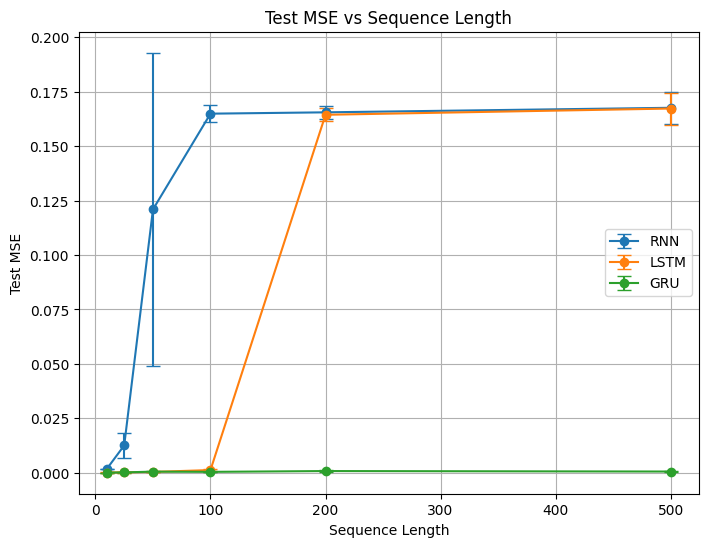

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for model_name in results_df["Model"].unique():
    subset = results_df[results_df["Model"] == model_name]
    
    plt.errorbar(
        subset["Seq_Len"],
        subset["MSE_mean"],
        yerr=subset["MSE_std"],
        marker='o',
        capsize=5,
        label=model_name
    )

plt.xlabel("Sequence Length")
plt.ylabel("Test MSE")
plt.title("Test MSE vs Sequence Length")
plt.legend()
plt.grid(True)
plt.show()

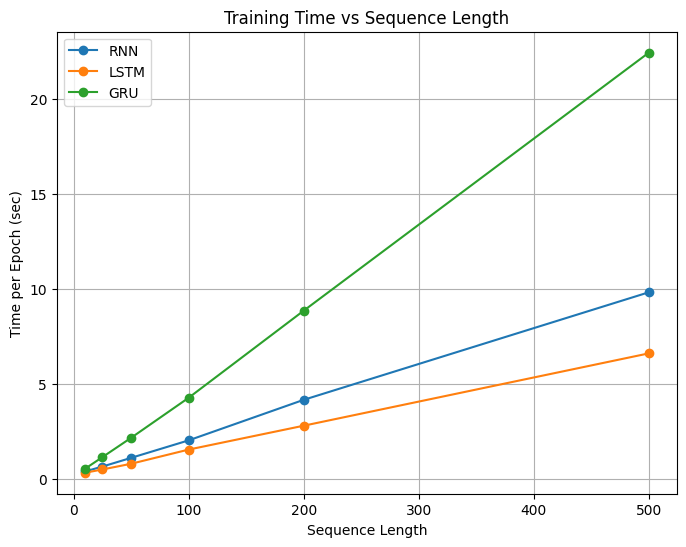

In [ ]:
plt.figure(figsize=(8,6))

for model_name in results_df["Model"].unique():
    subset = results_df[results_df["Model"] == model_name]
    
    plt.plot(
        subset["Seq_Len"],
        subset["Time_mean"],
        marker='o',
        label=model_name
    )

plt.xlabel("Sequence Length")
plt.ylabel("Time per Epoch (sec)")
plt.title("Training Time vs Sequence Length")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print(results_df.head())

In [ ]:
def plot_training_curves(model_results, seq_len):
    plt.figure(figsize=(8,6))
    
    for model_name, losses in model_results.items():
        plt.plot(losses, label=model_name)
    
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title(f"Training Curves (T={seq_len})")
plt.legend()
plt.grid(True)
plt.show()

<IPython.core.display.Javascript object>